In [1]:
from datasets import load_dataset

ds = load_dataset("DavidVivancos/MindBigData2022_MNIST_EP")
train = ds["train"]
test = ds["test"]

df_train = train.to_pandas()

/Users/hxwk/eeg_mnist_classifier/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
print(df_train.shape)  # (52022, 3585)

# Kolumny to 'label' - cyfra od 0 do 9, lub -1 gdy brak stymulacji
# Pozostałe 3584 kolumn to dane EEG z 14 elektrod x 256 próbek czasowych (14*256=3584)
# Próbka czasowa to 2 sekundy nagrania EEG, bo częstotliwość próbkowania to 128 Hz (256 próbek / 128 Hz = 2 sekundy)
# Czyli wiersz reprezentuje jedno nagranie napięcia EEG z 14 elektrod przez 2 sekundy
# Format kolumn to {kanał}-{numer_próbki}, np. 'AF3-0'

# Kanały EEG w kolejności kolumn:
# | Nr | Kanał | Pozycja        | Region mózgu              |
# |----|-------|----------------|---------------------------|
# | 1  | AF3   | L przedczołowy | planowanie, uwaga         |
# | 2  | F7    | L czołowy bocz.| język                     |
# | 3  | F3    | L czołowy      | decyzje                   |
# | 4  | FC5   | L czoł-centr.  | motoryka                  |
# | 5  | T7    | L skroniowy    | pamięć słuchowa           |
# | 6  | P7    | L ciemieniowy  | percepcja wzrokowa        |
# | 7  | O1    | L potyliczny   | kora wzrokowa (!)         |
# | 8  | O2    | R potyliczny   | kora wzrokowa (!)         |
# | 9  | P8    | R ciemieniowy  | percepcja wzrokowa        |
# | 10 | T8    | R skroniowy    | pamięć słuchowa           |
# | 11 | FC6   | R czoł-centr.  | motoryka                  |
# | 12 | F4    | R czołowy      | decyzje                   |
# | 13 | F8    | R czołowy bocz.| język                     |
# | 14 | AF4   | R przedczołowy | planowanie, uwaga         |
# L = lewa półkula, R = prawa półkula
# O1/O2 to kora wzrokowa - kluczowe kanały dla rozpoznawania bodźców wizualnych

print(df_train.columns)
print(df_train["label"].value_counts())

(52022, 3585)
Index(['label', 'AF3-0', 'AF3-1', 'AF3-2', 'AF3-3', 'AF3-4', 'AF3-5', 'AF3-6',
       'AF3-7', 'AF3-8',
       ...
       'AF4-246', 'AF4-247', 'AF4-248', 'AF4-249', 'AF4-250', 'AF4-251',
       'AF4-252', 'AF4-253', 'AF4-254', 'AF4-255'],
      dtype='str', length=3585)
label
 3    5294
 5    5256
 9    5250
 8    5241
 6    5218
 0    5212
 2    5196
 1    5080
 4    5079
 7    5069
-1     127
Name: count, dtype: int64


In [4]:
labels = df_train["label"].values  # (52022,)
eeg = df_train.drop("label", axis=1, inplace=False).values  # (52022, 3584)
# Reshape, aby mieć dane w postaci (próbki, kanały, epoki_czasowe)
eeg = eeg.reshape(-1, 14, 256)  # (52022, 14, 256)

<Axes: xlabel='label'>

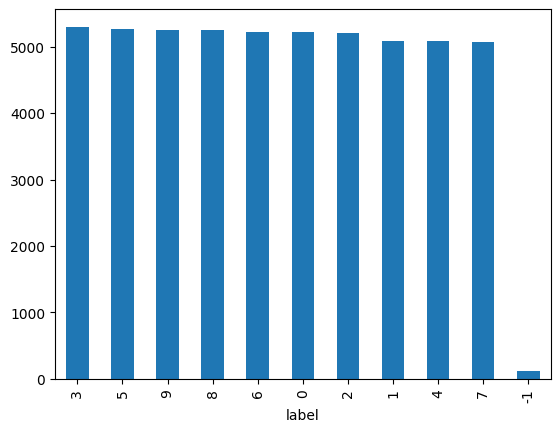

In [5]:
# Dobre zbalansowanie klas
df_train["label"].value_counts().plot(kind="bar")

In [6]:
print("Min per kanał")
print(eeg.min(axis=(0, 2)))
print("Max per kanał")
print(eeg.max(axis=(0, 2)))
print("Mean per kanał")
print(eeg.mean(axis=(0, 2)))
print("Std per kanał")
print(eeg.std(axis=(0, 2)))

print("Globalne:")
print("Min:", eeg.min())
print("Max:", eeg.max())
print("Mean:", eeg.mean())
print("Std:", eeg.std())

Min per kanał
[1852.516352 1852.516352 2027.179488 1852.516352 1852.516352 1852.516352
 1852.516352 1852.516352 1852.516352 1852.516352 1852.516352 1852.516352
 1852.516352 1852.516352]
Max per kanał
[6147.483647 6147.483647 6147.483647 6147.483647 6147.483647 6147.483647
 6076.465482 6147.483647 6147.483647 6147.483647 5996.378698 6147.483647
 6147.483647 6147.483647]
Mean per kanał
[4381.75346485 4514.69715433 4531.48097269 4266.23136684 4491.22556455
 4191.63576556 4441.8092023  4208.40888023 4231.5673376  4497.59178694
 4202.57884125 4636.49420395 3982.01553503 4045.50076021]
Std per kanał
[114.23956494  84.91628366  34.56716629  57.5885318   96.73400341
  75.11176478  38.83796051  63.07639878  35.30917427  87.9075629
  51.0055595   68.11812565  93.71541769  54.30719385]
Globalne:
Min: 1852.516352
Max: 6147.483647
Mean: 4330.213631167655
Std: 203.02476166432737


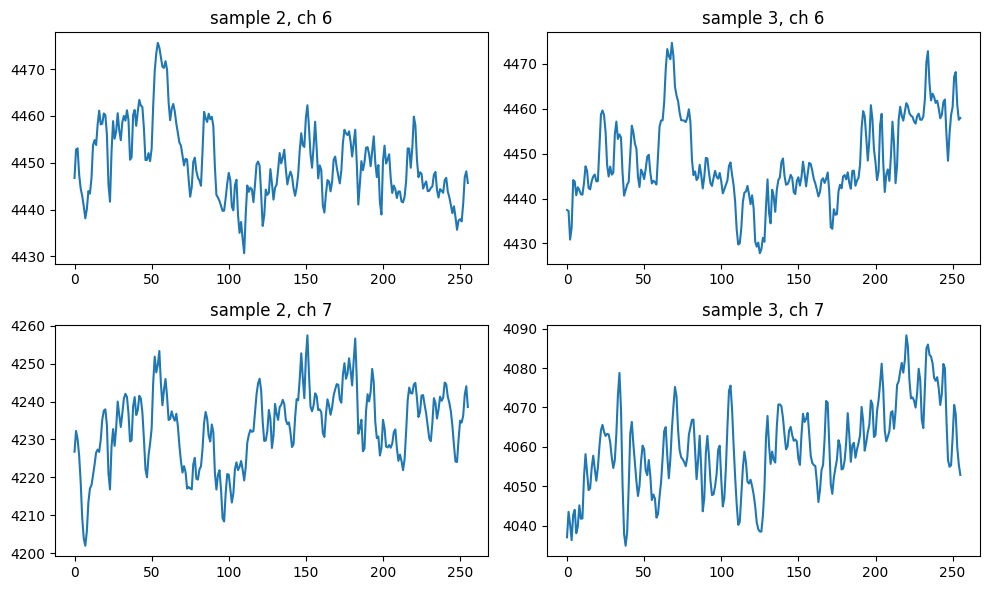

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(10, 6))

# Wizualizujemy, jak wyglądają sygnały EEG dla kanałów O1 i O2
# odpowiedzialnych za wzrok, dla dwóch przykładowych próbek dla klasy '3'

samples = [2, 3]
vision_channels = [6, 7]  # O1, O2 - kory wzrokowe

selected = eeg[labels == 3]  # cyfra '3'

for row, ch in enumerate(vision_channels):
    for col, sample_idx in enumerate(samples):
        ax = axes[row, col]

        ax.plot(selected[sample_idx][ch])
        ax.set_title(f"sample {sample_idx}, ch {ch}")

plt.tight_layout()
plt.show()

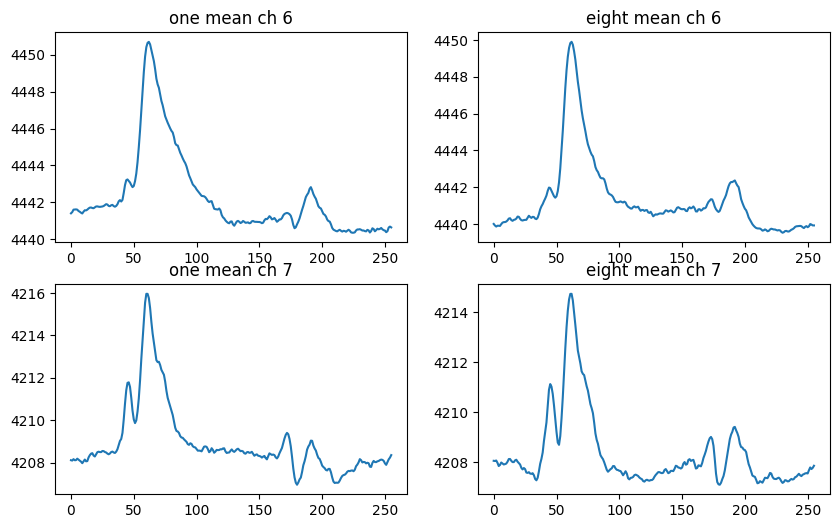

In [9]:
# Na poprzednich wykresach cięzko cokolwiek zauwazyć.
# Tutaj weźmy średnią po wszystkich próbkach, dla cyfr '1' i '8' (te cyfry chyba najbardziej się róznią od siebie).

one = eeg[labels == 1]  # (nepochs, 14, 256)
eight = eeg[labels == 8]  # (nepochs, 14, 256)

mean1 = one.mean(axis=(0))  # (14, 256)
mean2 = eight.mean(axis=(0))  # (14, 256)

fig, axes = plt.subplots(2, 2, figsize=(10, 6))

for row, ch in enumerate(vision_channels):
    ax1 = axes[row, 0]
    ax2 = axes[row, 1]

    ax1.plot(mean1[ch])
    ax1.set_title(f"one mean ch {ch}")

    ax2.plot(mean2[ch])
    ax2.set_title(f"eight mean ch {ch}")

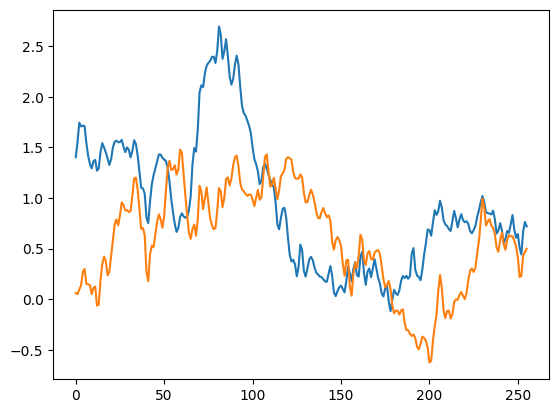

In [10]:
# Juz zaczyna widać jakieś minimalne róznice, ale nadal są bardzo subtelne.
# Zwizualizujmy roznice tych średnich.

diff = (mean1 - mean2)[vision_channels]
plt.plot(diff.T)

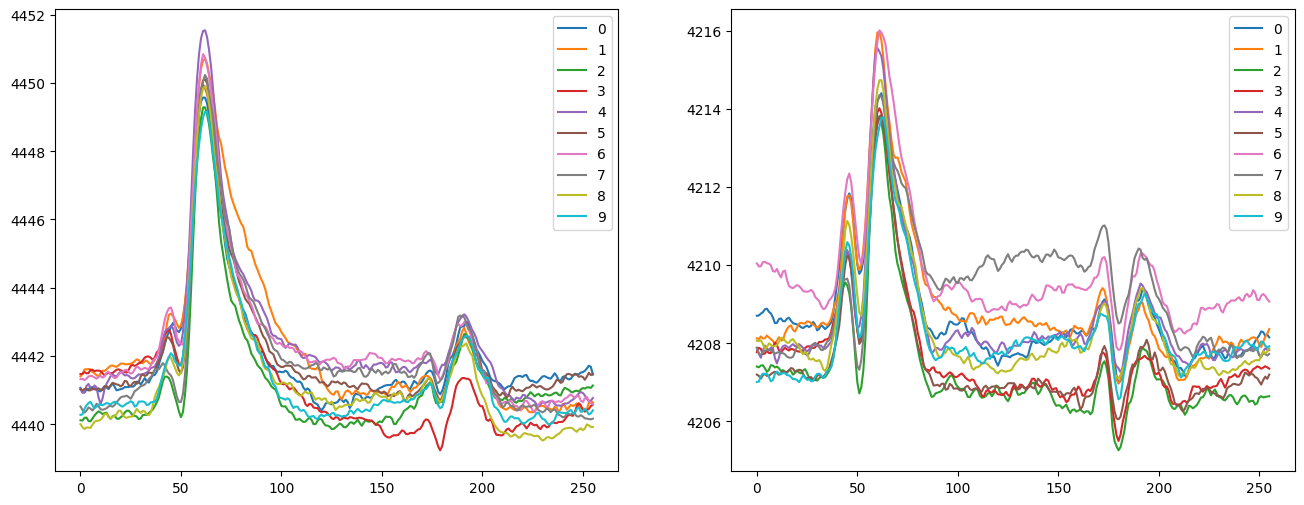

In [18]:
import numpy as np

# Ok, są JAKIEŚ róznice.
# To teraz pogrupujmy średnie per cyfra dla kazdej próbki i wyświetlmy je dla kanałów O1 i O2.

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

means = np.array([eeg[labels == i].mean(axis=0) for i in np.unique(labels) if i != -1])  # (10, 14, 256)

means_O1 = means[:, vision_channels[0], :]  # (10, 256)
means_O2 = means[:, vision_channels[1], :]  # (10, 256)

for i in range(10):
    axes[0].plot(means_O1[i], label=f"{i}")
    axes[1].plot(means_O2[i], label=f"{i}")
axes[0].legend()
axes[1].legend()

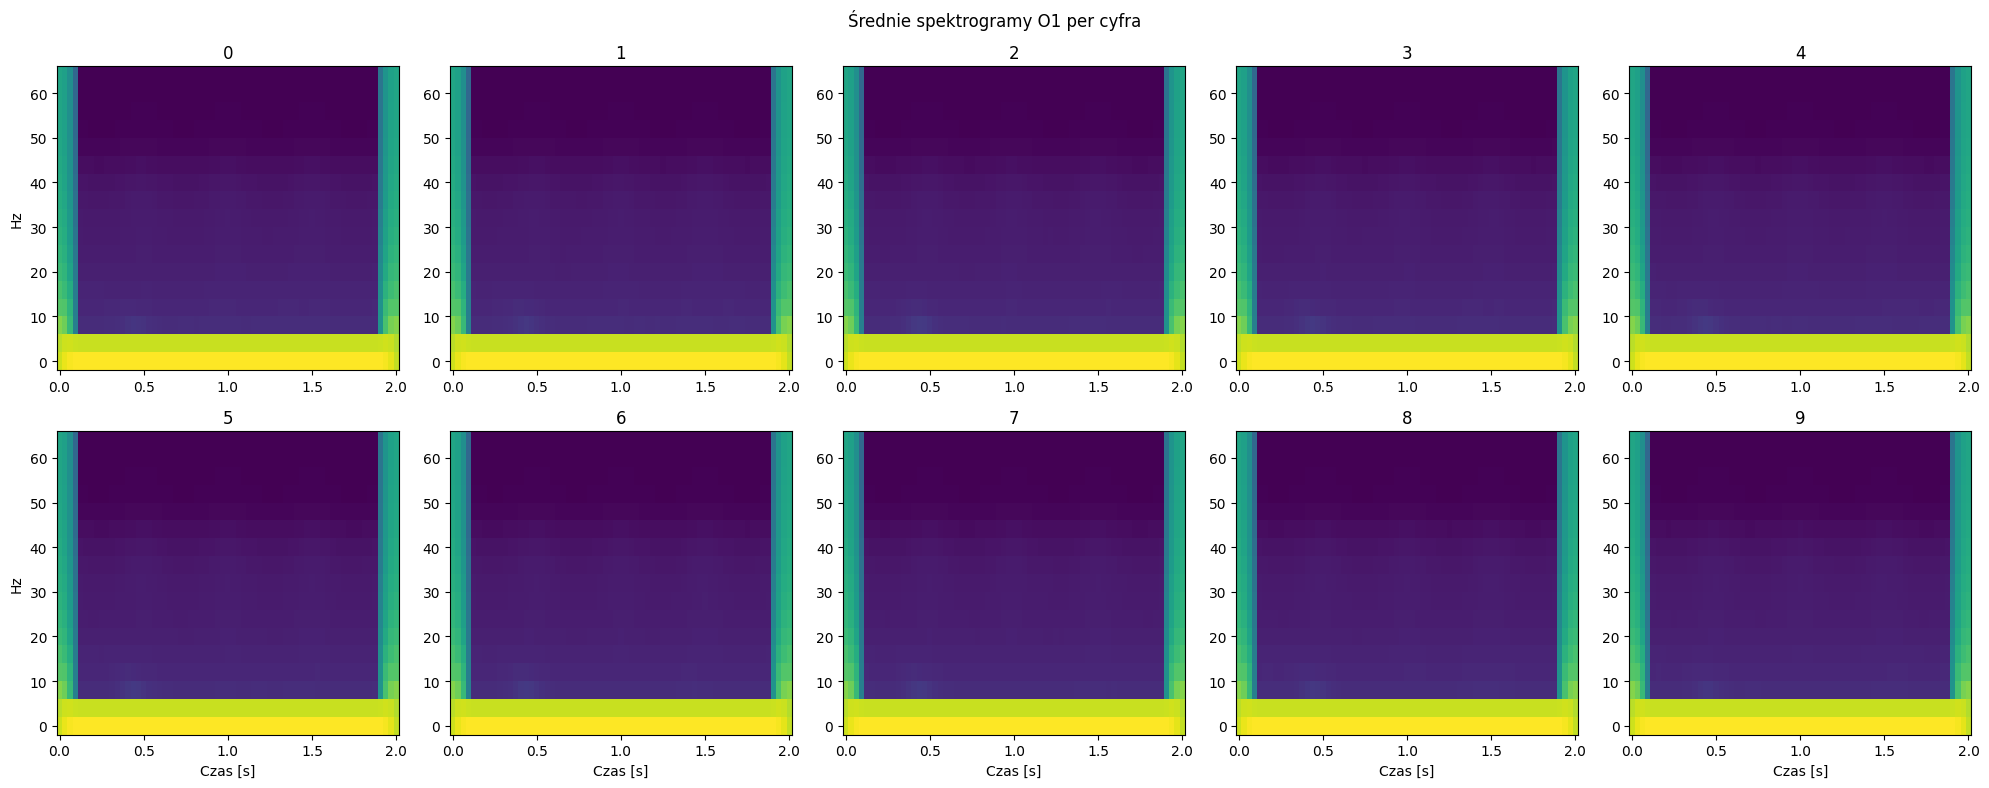

In [ ]:
from scipy.signal import stft

# Spektrogram to reprezentacja sygnału EEG w dwóch wymiarach jednocześnie:
# oś X to czas, oś Y to częstotliwość [Hz], kolor = natęzenie sygnału.
# Aby to policzyć uzywamy STFT (Short-Time Fourier Transform): przesuwamy krótkie
# okno czasowe po sygnale EEG i w kazdym oknie liczymy FFT (Fast-Fourier Transform), która
# rozkłada sygnał na składowe sinusoidalne o róznych częstotliwościach. Dzięki temu widzimy
# kiedy i na jakiej częstotliwości sygnał był aktywny.
# Kumari et al. (2021) traktowali spektrogramy EEG jako obrazy 2D i trenowali CNN,
# osiągając 91.29%. Natomiast inne papery osiągały lepsze wyniki, uzywajac surowego sygnału...

# Wynik: na średnich spektrogramach per cyfra brak widocznych róznic.

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for digit in range(10):
    ax = axes[digit // 5, digit % 5]
    epochs_digit = eeg[labels == digit][:, vision_channels[0], :]  # O1
    # Średni spektrogram: STFT per epoka, potem średnia amplitud
    specs = []
    for ep in epochs_digit:
        f, t, Zxx = stft(ep, fs=128, nperseg=32, noverlap=28)
        specs.append(np.abs(Zxx))
    mean_spec = np.mean(specs, axis=0)
    ax.pcolormesh(t, f, np.log1p(mean_spec), shading="auto")  # skala logarytmiczna
    ax.set_title(digit)
    if digit % 5 == 0:
        ax.set_ylabel("Hz")
    if digit >= 5:
        ax.set_xlabel("Czas [s]")
plt.suptitle("Średnie spektrogramy O1 per cyfra")
plt.tight_layout()

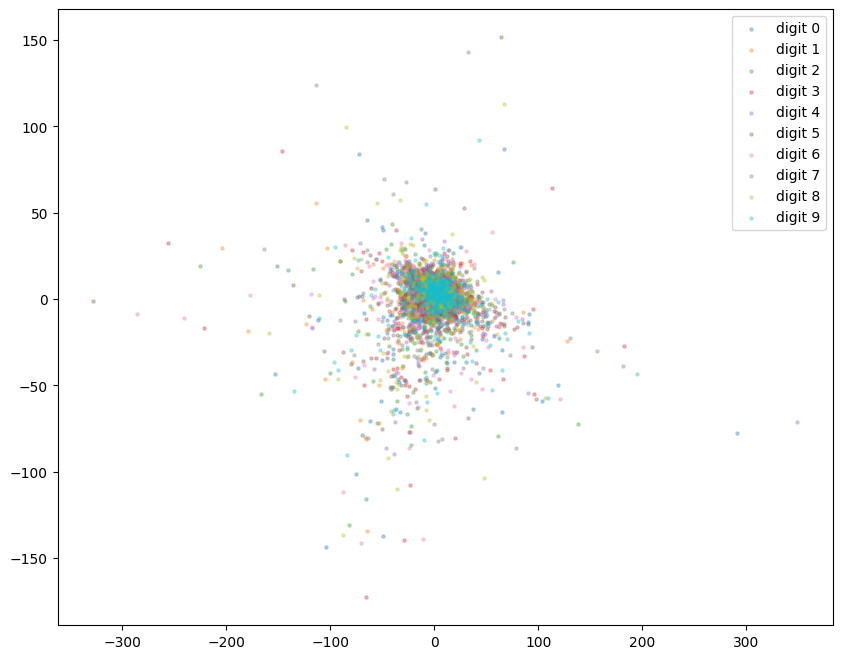

In [22]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Wrzucimy sobie 5000 próbek EEG (po 14 kanałów x 256 epok czasowych), aby zobaczyć, czy PCA będzie
# w stanie odseparować te cyfry w przestrzeni 2D. Zakładamy, ze pewnie nie.

idx = np.random.choice(len(eeg), 5000, replace=False)
X = eeg[idx].reshape(5000, -1)  # (5000, 3584)
y = labels[idx]  # (5000,)

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2, random_state=67)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
for i in range(10):
    mask = y == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f"digit {i}", alpha=0.3, s=5)
plt.legend()

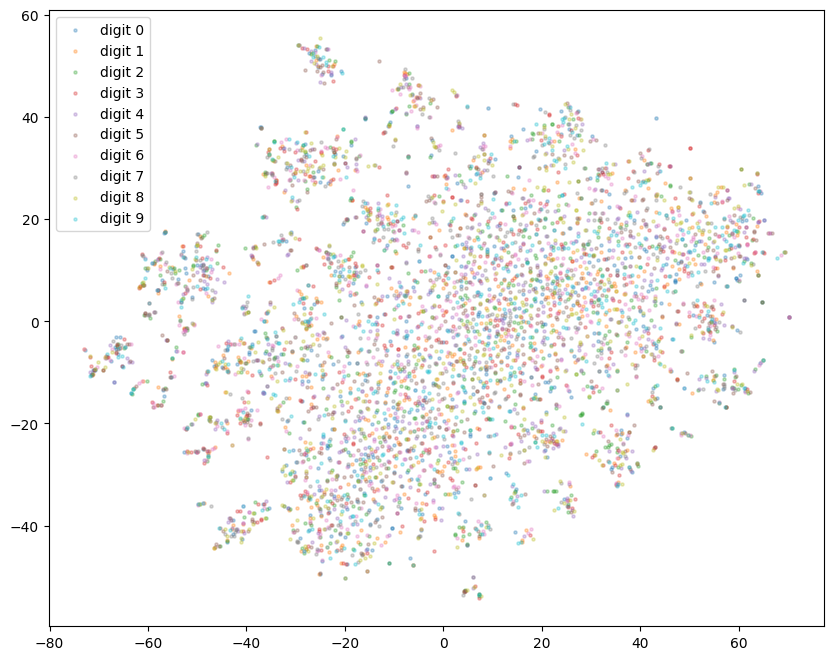

In [ ]:
from sklearn.manifold import TSNE

# To teraz jeszcze TSNE, która redukuje wymiarowość danych w sposób nieliniowy, próbując
# zachować lokalne sąsiedztwa danych.

tsne = TSNE(n_components=2, random_state=67)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
for i in range(10):
    mask = y == i
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1], label=f"digit {i}", alpha=0.3, s=5)
plt.legend()